*Environment setup*

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,StandardScaler,Binarizer



*Loading data from drive*

In [2]:
boston_df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv', sep = ",")
boston_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


*Data style visualization*

In [4]:
boston_df.tail()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [5]:
print("\ Dataset Informations")
boston_df.info()

\ Dataset Informations
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_580/1811508235.py:1: SyntaxWarning: invalid escape sequence '\ '
  print("\ Dataset Informations")


*Statistical information of my data*

In [6]:
print("\n Statistic Information")
boston_df.describe()


 Statistic Information


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


*Now, check data missing or not*

In [7]:
print("\n Missing Values Per Column")
boston_df.isnull().sum()


 Missing Values Per Column


,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [8]:
non_numeric_cols = boston_df.select_dtypes(include=['object', 'category']).columns
if len(non_numeric_cols) > 0:
    print("Non-numerical columns detected:")
    print(non_numeric_cols)
else:
    print("No non-numerical columns detected in the dataset.")

No non-numerical columns detected in the dataset.


*Finding correlation matrix*

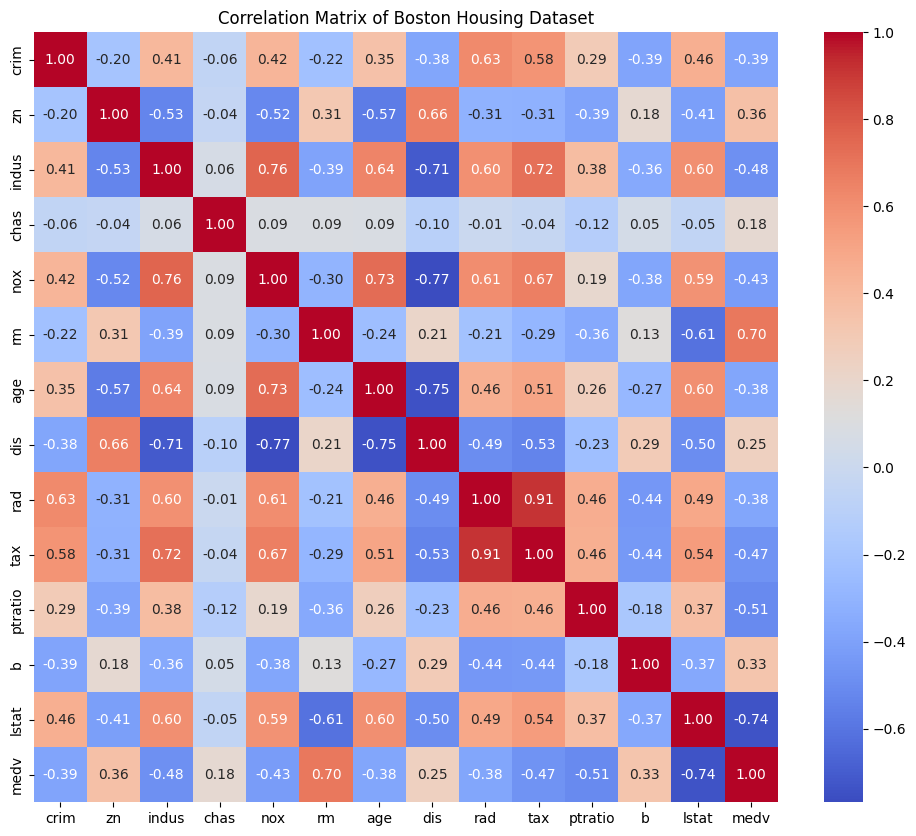

In [9]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(boston_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Boston Housing Dataset')
plt.show()

*Now, We start preprocessed the data *

In [10]:
X = boston_df.drop(['rad', 'medv'], axis = 1)
Y = boston_df['medv']

*Data scaling*

In [12]:
scaler = MinMaxScaler(feature_range = (0,1))

X = scaler.fit_transform(X)

pd.DataFrame(X).describe()

,0,1,2,3,4,5,6,7,8,9,10,11
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,0.040544,0.113636,0.391378,0.069170,0.349167,0.521869,0.676364,0.242381,0.422208,0.622929,0.898568,0.301409
std,0.096679,0.233225,0.251479,0.253994,0.238431,0.134627,0.289896,0.191482,0.321636,0.230313,0.230205,0.197049
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000851,0.000000,0.173387,0.000000,0.131687,0.445392,0.433831,0.088259,0.175573,0.510638,0.945730,0.144040
50%,0.002812,0.000000,0.338343,0.000000,0.314815,0.507281,0.768280,0.188949,0.272901,0.686170,0.986232,0.265728
75%,0.041258,0.125000,0.646628,0.000000,0.491770,0.586798,0.938980,0.369088,0.914122,0.808511,0.998298,0.420116
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


*Fitting data*

In [13]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
pd.DataFrame(X).describe()

,0,1,2,3,4,5,6,7,8,9,10,11
count,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02
mean,-2.808469e-17,-3.159528e-17,1.404235e-17,-3.510587e-17,1.123388e-16,-4.914821e-17,-3.510587e-17,5.616939e-17,-1.123388e-16,2.246775e-16,-2.808469e-17,1.544658e-16
std,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00
min,-4.197819e-01,-4.877224e-01,-1.557842e+00,-2.725986e-01,-1.465882e+00,-3.880249e+00,-2.335437e+00,-1.267069e+00,-1.313990e+00,-2.707379e+00,-3.907193e+00,-1.531127e+00
25%,-4.109696e-01,-4.877224e-01,-8.676906e-01,-2.725986e-01,-9.130288e-01,-5.686303e-01,-8.374480e-01,-8.056878e-01,-7.675760e-01,-4.880391e-01,2.050715e-01,-7.994200e-01
50%,-3.906665e-01,-4.877224e-01,-2.110985e-01,-2.725986e-01,-1.442174e-01,-1.084655e-01,3.173816e-01,-2.793234e-01,-4.646726e-01,2.748590e-01,3.811865e-01,-1.812536e-01
75%,7.396560e-03,4.877224e-02,1.015999e+00,-2.725986e-01,5.986790e-01,4.827678e-01,9.067981e-01,6.623709e-01,1.530926e+00,8.065758e-01,4.336510e-01,6.030188e-01
max,9.933931e+00,3.804234e+00,2.422565e+00,3.668398e+00,2.732346e+00,3.555044e+00,1.117494e+00,3.960518e+00,1.798194e+00,1.638828e+00,4.410519e-01,3.548771e+00


*Data binarization*

In [14]:
binarizer = Binarizer(threshold=0.5)
X = binarizer.fit_transform(X)
pd.DataFrame(X).describe()

,0,1,2,3,4,5,6,7,8,9,10,11
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.0,506.00000
mean,0.152174,0.171937,0.379447,0.069170,0.288538,0.237154,0.450593,0.272727,0.270751,0.428854,0.0,0.27668
std,0.359545,0.377699,0.485730,0.253994,0.453531,0.425759,0.498045,0.445803,0.444787,0.495402,0.0,0.44780
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000
75%,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.00000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.00000


### Preparing for Classification: Binarizing the Target Variable

To use a confusion matrix, our target variable (`medv`) needs to be categorical. I'll convert the continuous `medv` into a binary variable where values above the median are considered 'high value' (1) and values below or equal to the median are 'low value' (0).

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create a binary target variable from 'medv'
median_medv = Y.median()
Y_binary = (Y > median_medv).astype(int)

print(f"Median of 'medv' used for binarization: {median_medv}")
print(f"Value counts for the new binary target variable:\n{Y_binary.value_counts()}")

Median of 'medv' used for binarization: 21.2
Value counts for the new binary target variable:
medv
0    256
1    250
Name: count, dtype: int64


### Splitting Data and Training a Classifier

Now, we'll split our features (`X`) and the new binary target (`Y_binary`) into training and testing sets. Then, we'll train a Logistic Regression model, a common choice for binary classification.

In [16]:
# Split the data into training and testing sets
X_train, X_test, Y_binary_train, Y_binary_test = train_test_split(X, Y_binary, test_size=0.3, random_state=42)

# Initialize and train a Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' for small datasets
model.fit(X_train, Y_binary_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Generating and Visualizing the Confusion Matrix

Finally, we can predict on the test set and generate the confusion matrix to evaluate the classifier's performance.

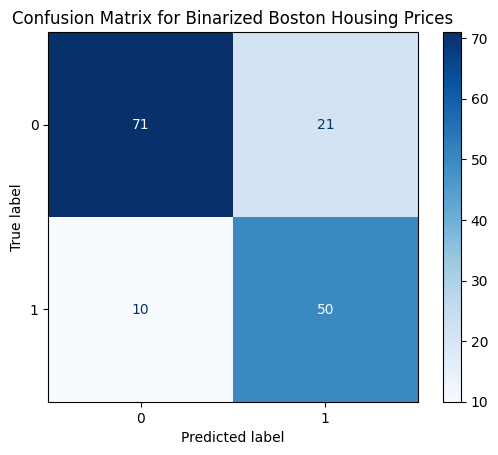

In [17]:
# Make predictions on the test set
Y_binary_pred = model.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(Y_binary_test, Y_binary_pred)

# Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]) # 0 for low, 1 for high
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Binarized Boston Housing Prices')
plt.show()